# `MEG`: ERF analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from mne.stats import permutation_cluster_test
from mne.stats import permutation_cluster_1samp_test

### ERF visualization

In [2]:
path = '/Users/shirley/mne-opm/NEU502-meg/bids/derivatives/preproc/sub-502/ses-01/meg/sub-502_ses-01_task-AVpilot_proc-clean_epo.fif'

epochs = mne.read_epochs(path, preload=True, verbose=False)

In [3]:
print(epochs.event_id)

{'aud': 2, 'audvis': 3, 'vis': 5}


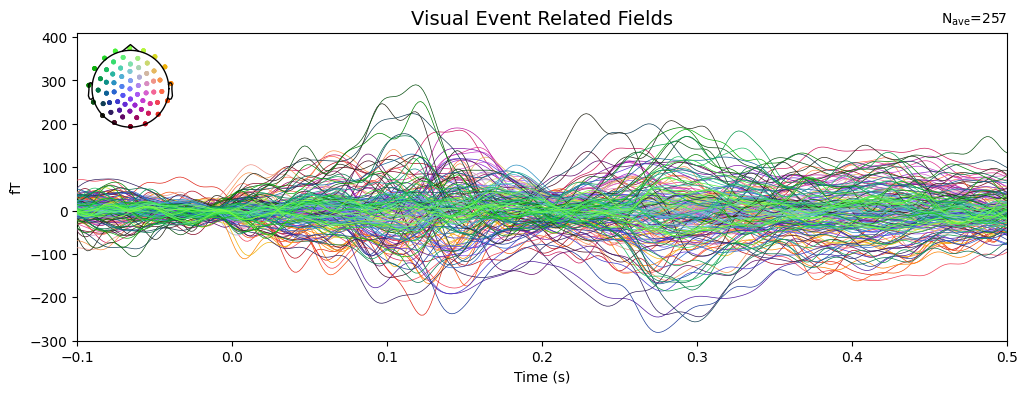

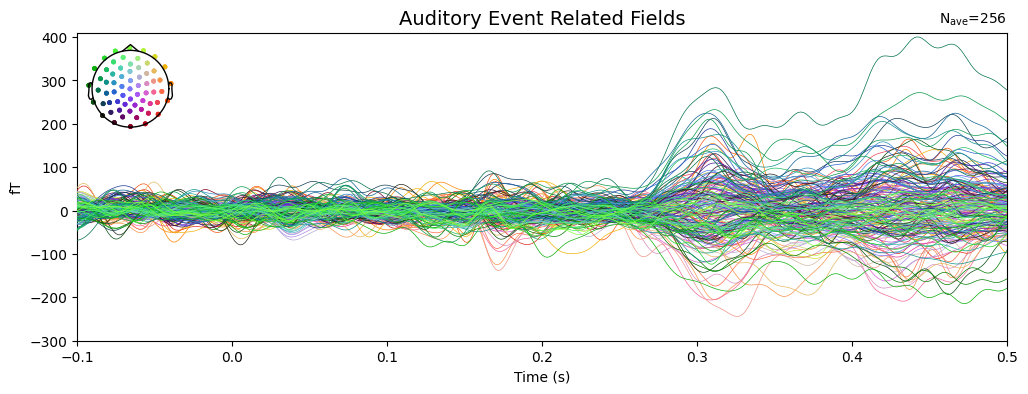

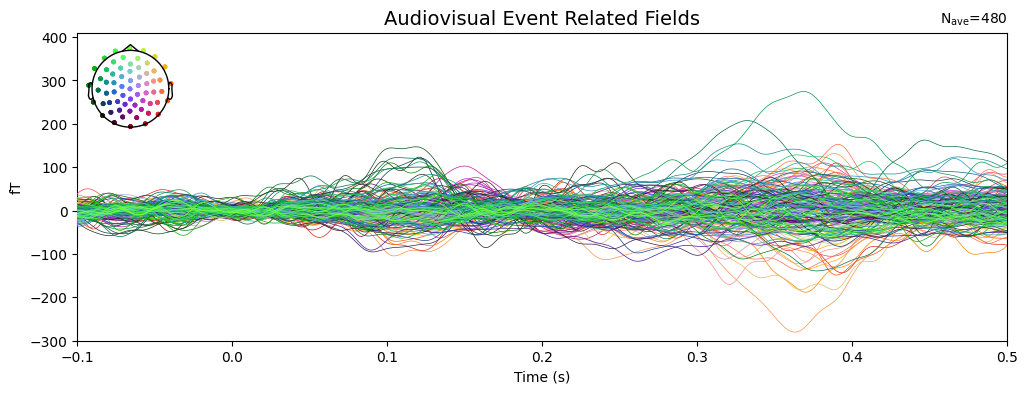

In [6]:
# Average within each condition
aud_evoked = epochs['aud'].average()
vis_evoked = epochs['vis'].average()
audvis_evoked = epochs['audvis'].average()

# Plot ERFs
fig, ax = plt.subplots(1,1,figsize=(12,4))
vis_evoked.plot(spatial_colors=True, xlim=(-0.1, 0.5), ylim=dict(mag=[-300, 410]), axes=ax, show=False)
ax.set_title('Visual Event Related Fields', fontsize=14)
plt.show();

fig, ax = plt.subplots(1,1,figsize=(12,4))
aud_evoked.plot(spatial_colors=True, xlim=(-0.1, 0.5), ylim=dict(mag=[-300, 410]), axes=ax, show=False)
ax.set_title('Auditory Event Related Fields', fontsize=14)
plt.show();

fig, ax = plt.subplots(1,1,figsize=(12,4))
audvis_evoked.plot(spatial_colors=True, xlim=(-0.1, 0.5), ylim=dict(mag=[-300, 410]), axes=ax, show=False)
ax.set_title('Audiovisual Event Related Fields', fontsize=14)
plt.show();

We can also plot the scalp topographic maps for each condition.

Text(0.5, 0.98, 'Audiovisual ERF Topomaps')

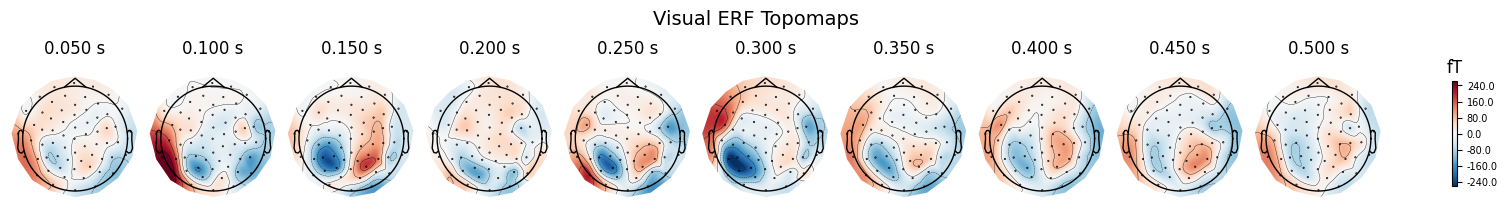

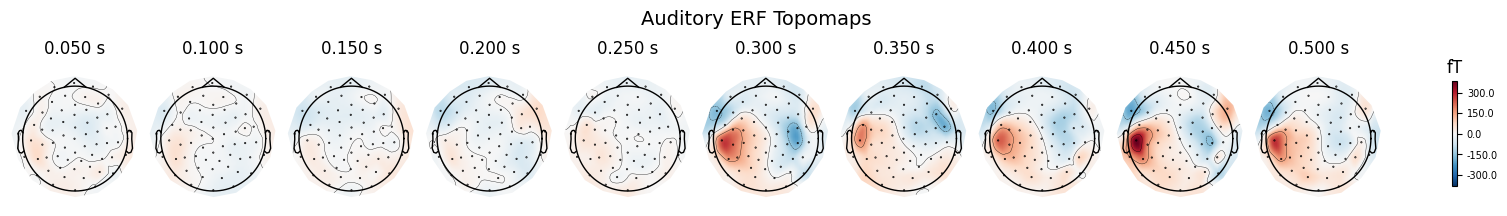

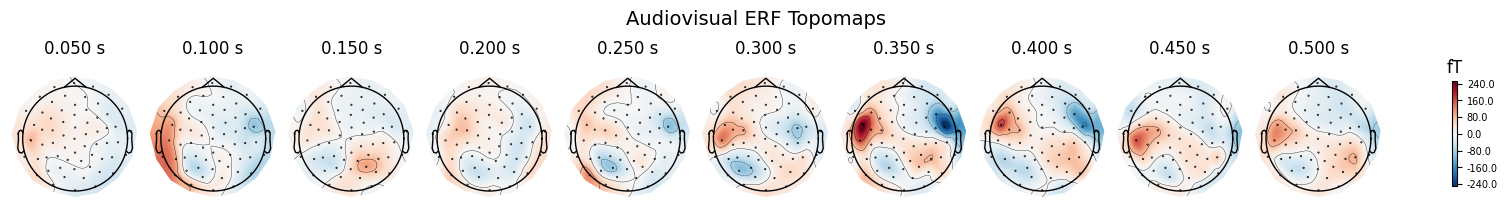

In [7]:
# Plot scalp topographies
fig=vis_evoked.plot_topomap(times=np.arange(0.05,0.55,0.05),show=False);
fig.suptitle('Visual ERF Topomaps', fontsize=14)

fig=aud_evoked.plot_topomap(times=np.arange(0.05,0.55,0.05),show=False);
fig.suptitle('Auditory ERF Topomaps', fontsize=14)

fig=audvis_evoked.plot_topomap(times=np.arange(0.05,0.55,0.05),show=False);
fig.suptitle('Audiovisual ERF Topomaps', fontsize=14)

In [13]:
# cluster-based permutation test comparing audio and visual conditions
X_aud = epochs['aud'].get_data(picks='meg')  # shape (n_epochs, n_channels, n_times)
X_vis = epochs['vis'].get_data(picks='meg')

T_obs, clusters, p_values, _ = permutation_cluster_test([X_aud, X_vis], n_permutations=1000, tail=0)

Using a threshold of 3.859721


/var/folders/dw/63nbkvqs0hg_8njhpybf214w0000gn/T/ipykernel_85714/678568291.py:5: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  T_obs, clusters, p_values, _ = permutation_cluster_test([X_aud, X_vis], n_permutations=1000, tail=0)


stat_fun(H1): min=4.184012973245315e-12 max=135.78024549745035
Running initial clustering …
Found 523 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

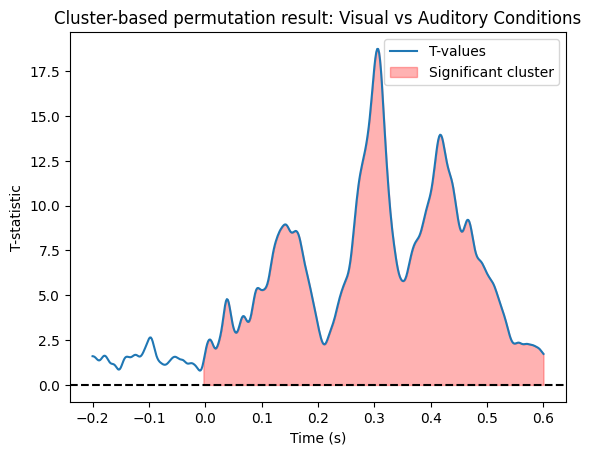

In [14]:
times = epochs.times
significant_mask = np.zeros_like(T_obs)
for i_c, c in enumerate(clusters):
    if p_values[i_c] < 0.05:
        significant_mask[c] = True

T_obs_plot = np.mean(T_obs, axis=0)  # average over channels

plt.figure()
plt.plot(times, T_obs_plot, label='T-values')
plt.axhline(0, color='black', linestyle='--')
plt.fill_between(times, T_obs_plot, where=significant_mask.any(axis=0), color='red', alpha=0.3, label='Significant cluster')
plt.xlabel('Time (s)')
plt.ylabel('T-statistic')
plt.legend()
plt.title('Cluster-based permutation result: Visual vs Auditory Conditions')
plt.show()

Text(0.5, 0.98, 'Topographic Map of Visual–Auditory Difference at Peak Effect')

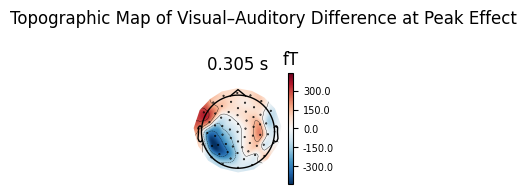

In [16]:
# find the timepoint with maximum contrast statistics
max_t_idx = np.argmax(np.abs(T_obs_plot))
evoked_diff = mne.combine_evoked([vis_evoked, aud_evoked], weights=[+1, -1])

#'Topomap at peak cluster time'
fig=evoked_diff.plot_topomap(times=evoked_diff.times[max_t_idx], ch_type='mag', time_unit='s',show=False);
fig.suptitle("Topographic Map of Visual–Auditory Difference at Peak Effect")

Text(0.5, 0.98, 'Topographic Map of Visual–Auditory Difference Across Time')

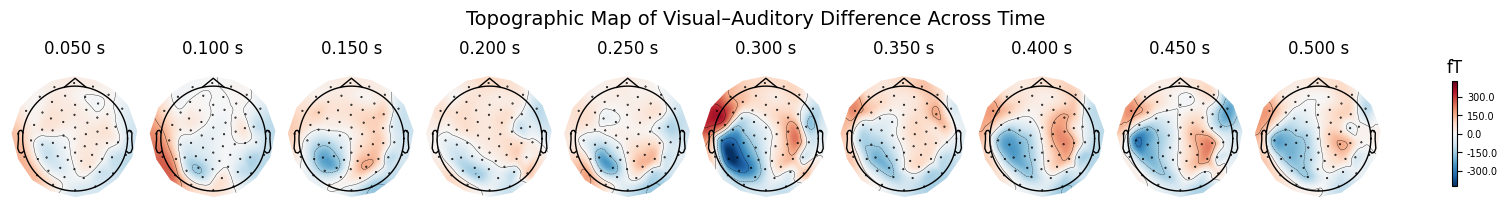

In [17]:
fig=evoked_diff.plot_topomap(times=np.arange(0.05,0.55,0.05),show=False);
fig.suptitle('Topographic Map of Visual–Auditory Difference Across Time', fontsize=14)

In [18]:
X_av = epochs['audvis'].get_data(picks='meg')

# AV vs Auditory
T_av_aud, clusters_av_aud, pvals_av_aud, _ = permutation_cluster_test([X_av, X_aud], n_permutations=1000)

# AV vs Visual
T_av_vis, clusters_av_vis, pvals_av_vis, _ = permutation_cluster_test([X_av, X_vis], n_permutations=1000)

Using a threshold of 3.854159


/var/folders/dw/63nbkvqs0hg_8njhpybf214w0000gn/T/ipykernel_85714/1969729500.py:4: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  T_av_aud, clusters_av_aud, pvals_av_aud, _ = permutation_cluster_test([X_av, X_aud], n_permutations=1000)


stat_fun(H1): min=4.340507028804209e-10 max=64.36342971426224
Running initial clustering …
Found 597 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 3.854142


/var/folders/dw/63nbkvqs0hg_8njhpybf214w0000gn/T/ipykernel_85714/1969729500.py:7: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  T_av_vis, clusters_av_vis, pvals_av_vis, _ = permutation_cluster_test([X_av, X_vis], n_permutations=1000)


stat_fun(H1): min=2.5054487052317336e-10 max=55.43924214083128
Running initial clustering …
Found 626 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

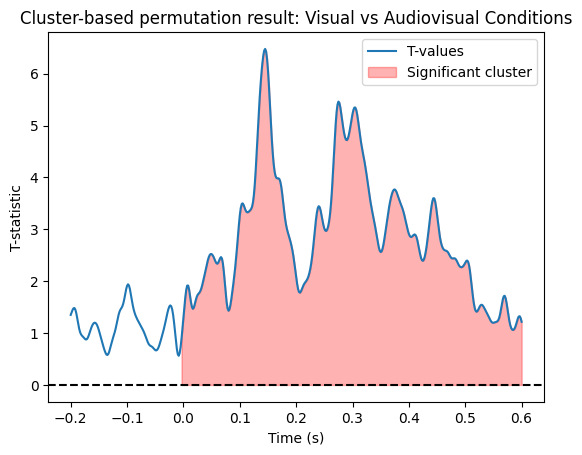

In [19]:
# AV vs VIS
times = epochs.times
significant_mask = np.zeros_like(T_av_vis)
for i_c, c in enumerate(clusters):
    if p_values[i_c] < 0.05:
        significant_mask[c] = True

T_av_vis_plot = np.mean(T_av_vis, axis=0)  # average over channels

plt.figure()
plt.plot(times, T_av_vis_plot, label='T-values')
plt.axhline(0, color='black', linestyle='--')
plt.fill_between(times, T_av_vis_plot, where=significant_mask.any(axis=0), color='red', alpha=0.3, label='Significant cluster')
plt.xlabel('Time (s)')
plt.ylabel('T-statistic')
plt.legend()
plt.title('Cluster-based permutation result: Visual vs Audiovisual Conditions')
plt.show()

Text(0.5, 0.98, 'Topographic map of Visual-Audiovisual Difference around 100ms')

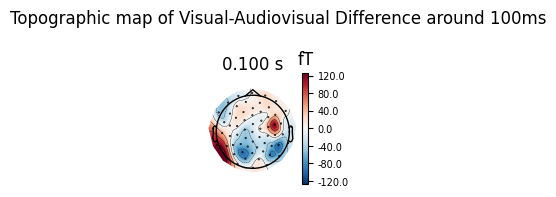

In [20]:
# define a window
tmin, tmax = 0.08, 0.12

# find time indices corresponding to that window
time_mask = (epochs.times >= tmin) & (epochs.times <= tmax)

# get T-values in that time window
T_window = T_av_vis[:, time_mask]

# find the peak t-value and its time index
peak_chan_idx, peak_time_rel_idx = np.unravel_index(np.argmax(np.abs(T_window)), T_window.shape)

# convert relative time index to full time index
peak_time_idx = np.where(time_mask)[0][peak_time_rel_idx]

# plot the topomap
evoked_diff = mne.combine_evoked(
    [epochs['vis'].average(), epochs['audvis'].average()],
    weights=[1, -1]
)

fig = evoked_diff.plot_topomap(
    times=evoked_diff.times[peak_time_idx],
    ch_type='mag',
    time_unit='s',
    show=False
)
fig.suptitle("Topographic map of Visual-Audiovisual Difference around 100ms")

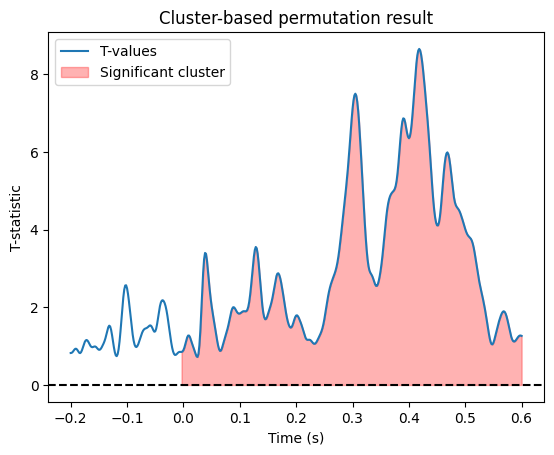

In [21]:
times = epochs.times
significant_mask = np.zeros_like(T_av_aud)
for i_c, c in enumerate(clusters):
    if p_values[i_c] < 0.05:
        significant_mask[c] = True

T_av_aud_plot = np.mean(T_av_aud, axis=0)  # average over channels

plt.figure()
plt.plot(times, T_av_aud_plot, label='T-values')
plt.axhline(0, color='black', linestyle='--')
plt.fill_between(times, T_av_aud_plot, where=significant_mask.any(axis=0), color='red', alpha=0.3, label='Significant cluster')
plt.xlabel('Time (s)')
plt.ylabel('T-statistic')
plt.legend()
plt.title('Cluster-based permutation result')
plt.show()

Text(0.5, 0.98, 'Topomap difference (~300 ms, Auditory - Audiovisual)')

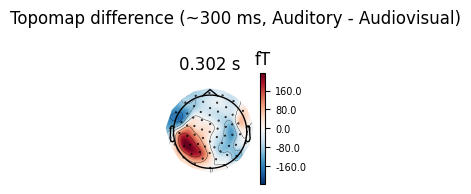

In [23]:
tmin, tmax = 0.3, 0.5

time_mask = (epochs.times >= tmin) & (epochs.times <= tmax)
T_window = T_av_aud[:, time_mask]

peak_chan_idx, peak_time_rel_idx = np.unravel_index(np.argmax(np.abs(T_window)), T_window.shape)
peak_time_idx = np.where(time_mask)[0][peak_time_rel_idx]

evoked_diff = mne.combine_evoked(
    [epochs['aud'].average(), epochs['audvis'].average()],
    weights=[1, -1]
)

fig = evoked_diff.plot_topomap(
    times=evoked_diff.times[peak_time_idx],
    ch_type='mag',
    time_unit='s',
    show=False
)
fig.suptitle("Topomap difference (~300 ms, Auditory - Audiovisual)")

In [34]:
X_av_full = epochs['audvis'].get_data(picks='meg')
X_aud = epochs['aud'].get_data(picks='meg')
X_vis = epochs['vis'].get_data(picks='meg')

# Randomly sample 256 trials from AV
np.random.seed(28)
rand_idx = np.random.choice(X_av_full.shape[0], size=256, replace=False)
X_av_sampled = X_av_full[rand_idx]

# truncate to 256 trials
X_aud = X_aud[:256]
X_vis = X_vis[:256]

# sum each A trial with a randomly shuffled V trial
X_sum = X_aud + X_vis[np.random.permutation(X_vis.shape[0])]

# compute the difference (AV - A+V)
X_diff = X_av_sampled - X_sum

In [35]:
T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(
    X_diff, n_permutations=1000, tail=0, threshold=None
)

Using a threshold of 1.969311
stat_fun(H1): min=-5.547565198713312 max=5.258739439769668
Running initial clustering …
Found 704 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

In [36]:
significant_mask = np.zeros_like(T_obs, dtype=bool)
for i, c in enumerate(clusters):
    if p_values[i] < 0.05:
        significant_mask[c] = True

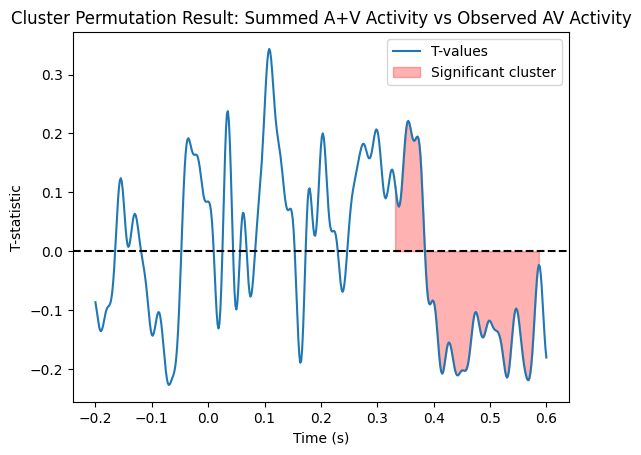

In [38]:
T_obs_plot = np.mean(T_obs, axis=0)  # average over channels

plt.figure()
plt.plot(times, T_obs_plot, label='T-values')
plt.axhline(0, color='black', linestyle='--')
plt.fill_between(times, T_obs_plot, where=significant_mask.any(axis=0), color='red', alpha=0.3, label='Significant cluster')
plt.xlabel('Time (s)')
plt.ylabel('T-statistic')
plt.legend()
plt.title('Cluster Permutation Result: Summed A+V Activity vs Observed AV Activity')
plt.show()

Text(0.5, 0.98, 'Topographic Map of Summed–Audiovisual Difference Across Time')

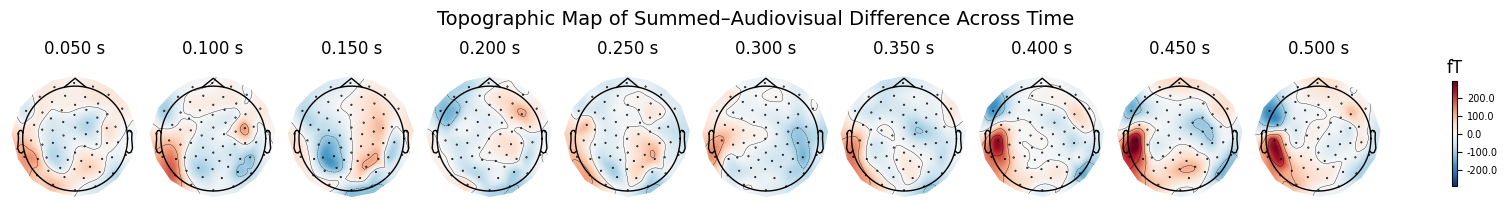

In [41]:
evoked_diff = mne.combine_evoked([audvis_evoked, aud_evoked, vis_evoked], weights=[-1, +1, +1])

fig=evoked_diff.plot_topomap(times=np.arange(0.05,0.55,0.05),show=False);
fig.suptitle('Topographic Map of Summed–Audiovisual Difference Across Time', fontsize=14)

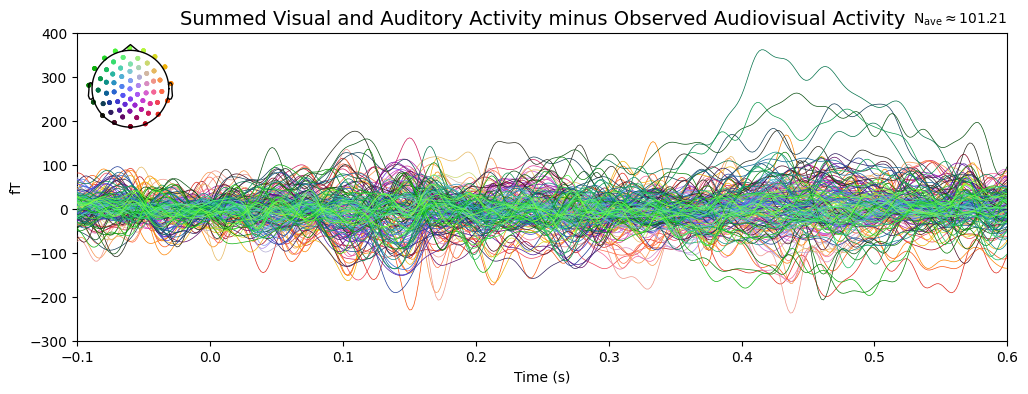

In [47]:
fig, ax = plt.subplots(1,1,figsize=(12,4))
evoked_diff.plot(spatial_colors=True, xlim=(-0.1, 0.6), ylim=dict(mag=[-300, 400]), axes=ax, show=False)
ax.set_title('Summed Visual and Auditory Activity minus Observed Audiovisual Activity', fontsize=14)
plt.show();